# 工业企业财务数据

## 1 初识工业企业财务数据

利润表|资产负债表
-|-
营业收入|货币资金
-营业成本|应收账款
**毛利**|存货
-营业税金及附加|其它流动资产
-销售费用|**流动资产**
-管理费用|固定资产
-财务费用|无形资产
-资产减值损失|其他非流动性资产
+公允价值变动收益|**总资产**
+投资收益|流动负债
**营业利润**|非流动负债
+营业外收入|**总负债**
-营业外支出|**所有者权益**
**利润总额**
-所得税
**净利润**

## 2 工业企业利润表解读

### 2.1 工业企业利润表结构分析

统计局按月公布工业企业的营业收入、利润总额，比a股上市公司的季报时效性更高。

2019年后主营业务收入（成本）被营业收入（成本）替代，因为两者差距比较小，可以直接衔接起来。

股票价格 = 市盈率（PE）*每股收益（EPS）

如果把利润总额增速近似看成EPS增速，那么分析工业企业利润增速可以帮助我们对股票定价。

In [57]:
import akshare as ak
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import re

# 指定支持中文的字体，例如SimHei或者Microsoft YaHei
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

figsize = (15,5)

In [ ]:
industryFinancialDf = ak.macro_china_nbs_nation(kind="月度数据", path="工业>工业企业主要经济指标", period="2011-")
industryFinancialDf = industryFinancialDf.transpose().iloc[::-1]

In [ ]:
ppiDf = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="价格指数>工业生产者出厂价格分类指数>工业生产者出厂价格指数(上年同期=100)",
    period="2011-",
)
ppiDf = ppiDf.transpose().iloc[::-1]

In [ ]:
gyzjzDf = ak.macro_china_nbs_nation(
    kind="月度数据", path="工业>工业增加值增长速度", period="2011-"
)
gyzjzDf = gyzjzDf.transpose().iloc[::-1]

In [ ]:
profitByCategoriesDf = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2018-至今)>工业企业利润总额",
    period="2018-",
)
profitByCategoriesDf = profitByCategoriesDf.transpose().iloc[::-1]

### 2.2 工业企业利润数据分析

#### 2.2.1 从总量角度观察

工业企业利润=营业收入*利润率

那么可以把这个公式中的每一项往统计局公布的数据中套，找一些关联性强的指标进行分析。

工业企业利润变动的原因可以拆成3部分：量、价、利润率

1. 产量的变动可以通过工业增加值同比观察

    工业增加值同比，剔除了价格因素（ppi），所以是一个很纯粹的、只反映总产量（或者说实际总产值）变动的指标

2. 价格的变动可以通过ppi同比观察

3. 利润率的变动可以通过营业收入利润率观察（营业收入利润率= (营业收入-营业成本-税金及附加-期间费用)÷营业收入×100% ）


In [ ]:
industryFinancialDf2018 = industryFinancialDf.ffill().loc["2018年1月":]
profitRate2018 = (
    industryFinancialDf2018["营业利润_累计值(亿元)"]
    / industryFinancialDf2018["营业收入_累计值(亿元)"]
) / (
    industryFinancialDf2018["营业利润_上年同期累计值(亿元)"]
    / industryFinancialDf2018["营业收入_上年同期累计值(亿元)"]
) * 100 - 100

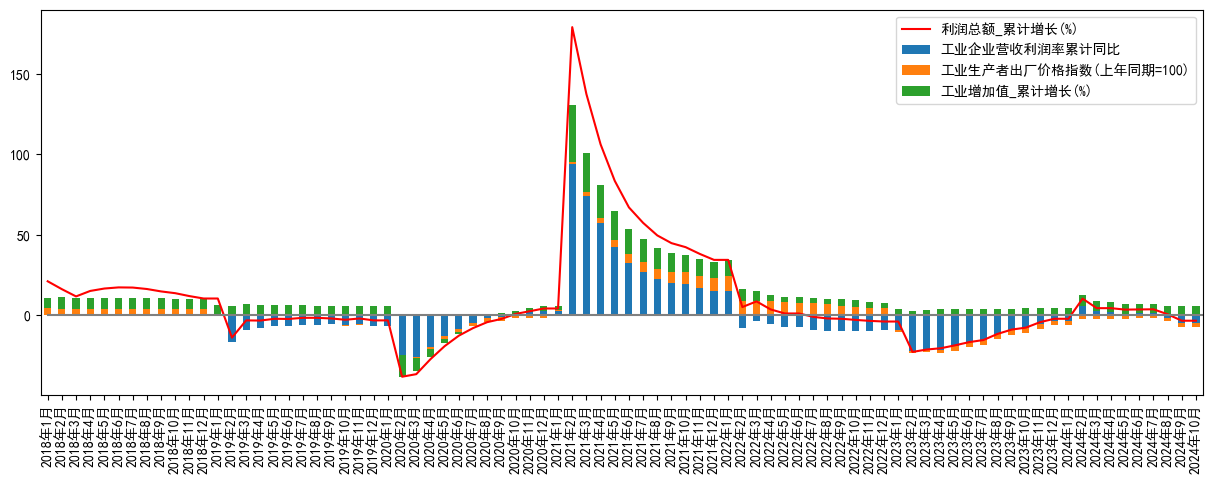

In [90]:
ax = pd.DataFrame(
    {
        "工业企业营收利润率累计同比": profitRate2018,
        "工业生产者出厂价格指数(上年同期=100)": ppiDf[
            "工业生产者出厂价格指数(上年同期=100)"
        ]
        .ffill()
        .loc["2018年1月":]
        - 100,
        "工业增加值_累计增长(%)": gyzjzDf["工业增加值_累计增长(%)"]
        .ffill()
        .loc["2018年1月":],
    }
).plot(figsize=(15, 5), kind="bar", stacked=True)
ax.plot(
    industryFinancialDf["利润总额_累计增长(%)"].ffill().loc["2018年1月":],
    label="利润总额_累计增长(%)",
    color="r",
)
ax.plot([0]*industryFinancialDf["利润总额_累计增长(%)"].size, color="gray")
plt.legend()

#### 2.2.2 从行业角度观察（待完善）

In [ ]:
import hy

industryHy = hy.getIndustryHYCode()
industryHy40 = []
for (code, name) in industryHy:
    if len(code) == 2:
        industryHy40.append((code, name))

<Axes: title={'center': '2020年工业行业利润总额前20'}>

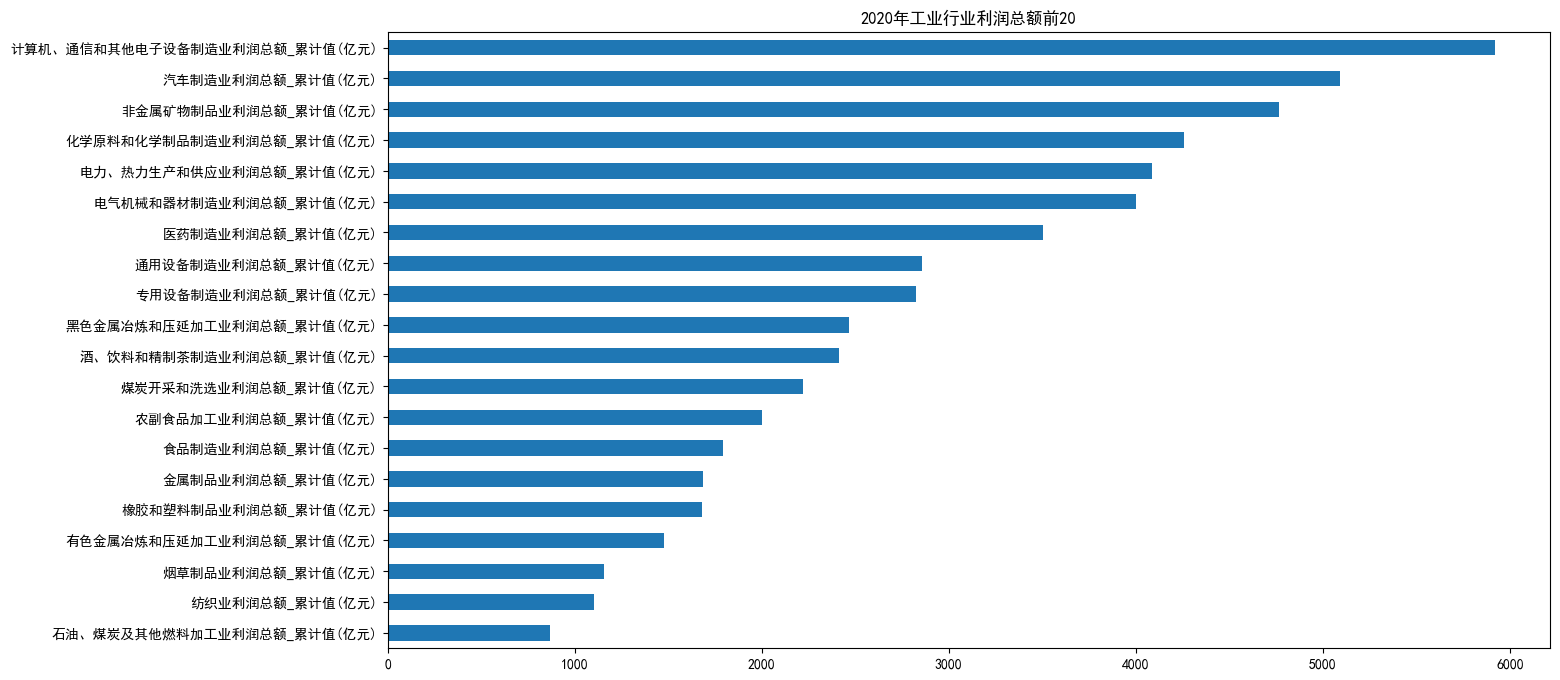

In [48]:
values = []
index = []
for code, name in industryHy40:
    values.append(
        profitByCategoriesDf.loc["2020年12月"][f"{name}利润总额_累计值(亿元)"]
    )
    index.append(f"{name}利润总额_累计值(亿元)")
s = pd.Series(values, index=index).sort_values(ascending=True)
s.iloc[-20:].plot.barh(figsize=(15, 8), title="2020年工业行业利润总额前20")

##### 2.2.2.1 上中下游企业利润总额增长率

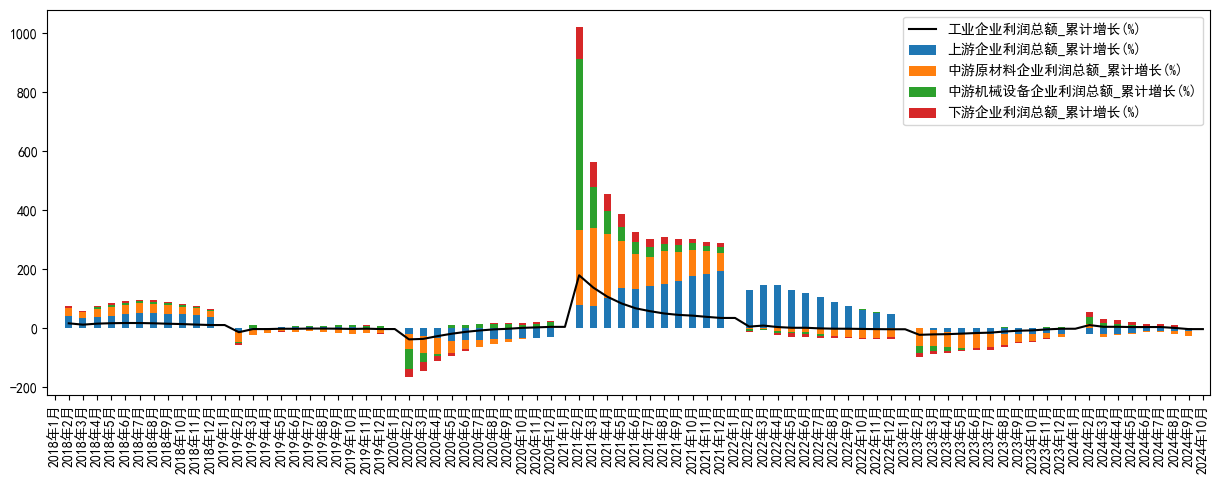

In [47]:
[upperIndustries, middleIndustries1, middleIndustries2, lowerIndustries] = (
    hy.getUpperAndLowerCooperation()
)


def getWeightedSum(list):
    xDf = profitByCategoriesDf[
        [f"{name}利润总额_累计值(亿元)" for name in list]
    ].rename(columns=dict([(f"{name}利润总额_累计值(亿元)", name) for name in list]))
    yDf = profitByCategoriesDf[
        [f"{name}利润总额_上年同期累计值(亿元)" for name in list]
    ].rename(columns=dict([(f"{name}利润总额_上年同期累计值(亿元)", name) for name in list]))
    rate = profitByCategoriesDf[
        [f"{name}利润总额_累计增长(%)" for name in list]
    ].rename(columns=dict([(f"{name}利润总额_累计增长(%)", name) for name in list]))
    total = yDf.sum(axis=1)
    weight = yDf.apply(lambda r: r / total, axis=0)
    return (weight * rate).sum(axis=1)

ax = pd.DataFrame({
    "上游企业利润总额_累计增长(%)": getWeightedSum(upperIndustries),
    "中游原材料企业利润总额_累计增长(%)": getWeightedSum(middleIndustries1),
    "中游机械设备企业利润总额_累计增长(%)": getWeightedSum(middleIndustries2),
    "下游企业利润总额_累计增长(%)": getWeightedSum(lowerIndustries),
}).plot.bar(figsize=(15,5), stacked=True)

ax.plot(profitByCategoriesDf["工业企业利润总额_累计增长(%)"].ffill(), label="工业企业利润总额_累计增长(%)", c="black")
plt.legend()


In [88]:
# (profitByCategoriesDf["工业企业利润总额_累计值(亿元)"] / profitByCategoriesDf["工业企业利润总额_上年同期累计值(亿元)"] - 1) * 100
# profitByCategoriesDf["工业企业利润总额_累计增长(%)"].ffill().plot()

# for name in profitByCategoriesDf.columns[3::3]:
#     if name[:-12] not in [name for (code, name) in industryHy40]:
#         print(name[:-12])

names = ["采矿业", "制造业", "电力、热力、燃气及水生产和供应业"]
names2 = [f"{name}利润总额_累计值(亿元)" for name in names]
profitByCategoriesDf[names2].sum(axis=1)

2018年1月         0.0
2018年2月      9689.0
2018年3月     15533.2
2018年4月     21271.8
2018年5月     27298.4
             ...   
2024年6月     35110.2
2024年7月     40991.7
2024年8月     46527.3
2024年9月     52281.7
2024年10月        0.0
Length: 82, dtype: float64

#### 2.2.3 从企业类型角度观察（待完善）

#### 2.2.4 2018年数据的争议

2018年，用工业企业利润总额累计值算出来的同比，明显小于官方公布的同比。

利润表、资产负债表其他指标业出现类似情况。

相关资料：
- https://www.stats.gov.cn/sj/zxfb/202302/t20230203_1900046.html
- https://finance.sina.com.cn/zl/stock/2018-09-26/zl-ifxeuwwr8308277.shtml

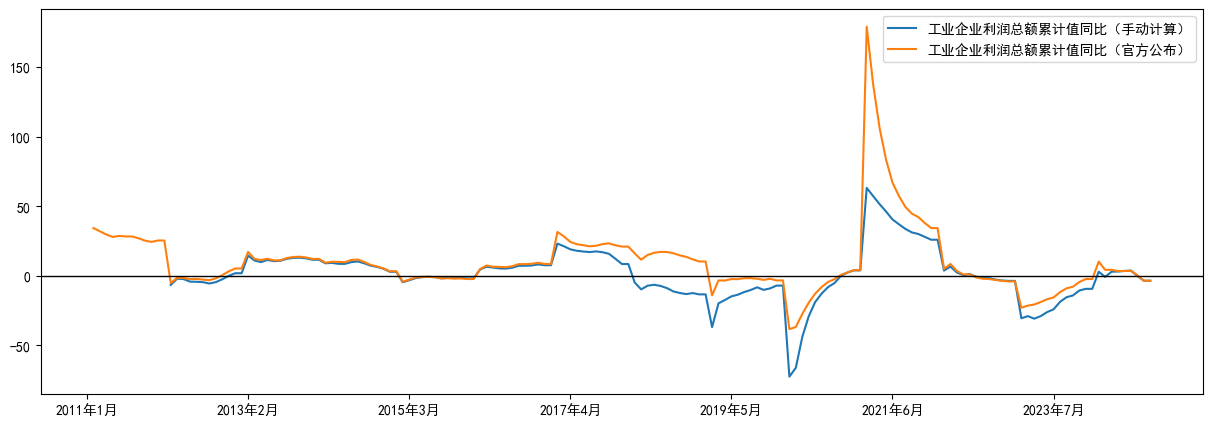

In [111]:
s1 = (
    industryFinancialDf["利润总额_累计值(亿元)"]
    - industryFinancialDf["利润总额_累计值(亿元)"].shift(12)
) / industryFinancialDf["利润总额_累计值(亿元)"] * 100

pd.DataFrame({
    "工业企业利润总额累计值同比（手动计算）": s1.ffill(),
    "工业企业利润总额累计值同比（官方公布）": industryFinancialDf['利润总额_累计增长(%)'].ffill()
}).plot(figsize=figsize)

# 零轴
plt.axhline(0, color='k', linestyle='-', linewidth=1)

### 2.3 工业企业资产负债表数据分析

#### 2.3.1 资产负债率

资产负债率显示了企业的杠杆情况

In [62]:
# (industryFinancialDf["负债合计_本月末(亿元)"] / industryFinancialDf["资产总计_本月末(亿元)"]).ffill().plot(figsize=figsize)
industryFinancialDf.columns

# industryFinancialDf["负债合计_本月末(亿元)"].shift(2)
# industryFinancialDf["负债合计_增减(%)"]

Index(['企业单位数_本月末(个)', '亏损企业_本月末(个)', '亏损企业_上年同期(个)', '亏损企业_增减(%)',
       '流动资产合计_本月末(亿元)', '流动资产合计_上年同期(亿元)', '流动资产合计_增减(%)', '应收账款_本月末(亿元)',
       '应收账款_上年同期(亿元)', '应收账款_增减(%)', '存货_本月末(亿元)', '存货_上年同期(亿元)', '存货_增减(%)',
       '产成品存货_本月末(亿元)', '产成品存货_上年同期(亿元)', '产成品存货_增减(%)', '资产总计_本月末(亿元)',
       '资产总计_上年同期(亿元)', '资产总计_增减(%)', '负债合计_本月末(亿元)', '负债合计_上年同期(亿元)',
       '负债合计_增减(%)', '主营业务收入_累计值(亿元)', '主营业务收入_上年同期累计值(亿元)', '主营业务收入_累计增长(%)',
       '主营业务成本_累计值(亿元)', '主营业务成本_上年同期累计值(亿元)', '主营业务成本_累计增长(%)',
       '主营业务税金及附加_累计值(亿元)', '主营业务税金及附加_上年同期累计值(亿元)', '主营业务税金及附加_累计增长(%)',
       '销售费用_累计值(亿元)', '销售费用_上年同期累计值(亿元)', '销售费用_累计增长(%)', '管理费用_累计值(亿元)',
       '管理费用_上年同期累计值(亿元)', '管理费用_累计增长(%)', '财务费用_累计值(亿元)', '财务费用_上年同期累计值(亿元)',
       '财务费用_累计增长(%)', '利息支出_累计值(亿元)', '利息支出_上年同期累计值(亿元)', '利息支出_累计增长(%)',
       '投资收益_累计值(亿元)', '投资收益_上年同期累计值(亿元)', '投资收益_累计增长(%)', '营业利润_累计值(亿元)',
       '营业利润_上年同期累计值(亿元)', '营业利润_累计增长(%)', '利润总额_累计值(亿元)', '利润总额_上年同期累计值(亿元)',
       '利润总额_累计增长(%)', '亏损企业亏损总额